# VQE — ground state del dimero al punto di lavoro del test 2

**Punto di lavoro:** $b/J=0.35$, $D/J=0.80$, $J=1$ — i parametri del "test 2"
in `relazione_test_parametri.md`.

**Contesto.** È il primo passo della fase VQE → ground state → correlazioni
dinamiche: il ground state trovato qui sostituirà $|00\rangle$ come stato
iniziale dell'evoluzione temporale, in vista del calcolo di correlazioni a
due tempi con un qubit ancilla (in attesa della risposta del relatore su
quale correlazione).

**Nessuna scelta nuova in questo notebook.** Hamiltoniana, ansatz e
metodologia di ottimizzazione sono esattamente quelli già validati e
decisi in `dimer_exact.py` e `confronto_ansatz_entangler.ipynb`; qui si
applicano a un singolo punto $(b,J,D)$ con l'obiettivo di uno stato preciso
a precisione macchina (non un confronto qualitativo fra ansatz).

## 1. Setup e self-test

Prima regola del progetto: verificare i blocchi elementari a precisione
macchina *prima* di guardare qualunque risultato fisico.

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import io

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator

from IPython.display import display, Image

def _mostra_figura(fig, out=None):
    # rende la figura come un unico blob PNG (evita il doppio rendering
    # del backend inline in alcuni frontend, es. VS Code Jupyter)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img = Image(data=buf.getvalue())
    if out is None:
        display(img)
    else:
        with out:
            out.clear_output(wait=True)
            display(img)

In [2]:
def rbs_block(qc, phi, q0=0, q1=1):
    # blocco M-conservante: H-CZ-Ry(phi)/Ry(-phi)-CZ-H.
    # stesso blocco usato in confronto_ansatz_entangler.ipynb per l'ansatz D
    # e per tutte le famiglie PMA: un'unica implementazione, riusata ovunque
    sub = QuantumCircuit(2, name="RBS")
    sub.h(0); sub.h(1); sub.cz(0, 1)
    sub.ry(phi, 0); sub.ry(-phi, 1)
    sub.cz(0, 1); sub.h(0); sub.h(1)
    qc.append(sub.to_gate(label="RBS"), [q0, q1])

def _givens_target(phi):
    c, s = np.cos(phi), np.sin(phi)
    G = np.eye(4, dtype=complex)
    G[1, 1] = c; G[1, 2] = -s; G[2, 1] = s; G[2, 2] = c
    return G

print("self-test blocco RBS (deve riprodurre G(phi) a precisione macchina):")
for phi in [0.3, 0.7, -0.5, 1.9]:
    qc = QuantumCircuit(2); rbs_block(qc, phi)
    err = np.max(np.abs(Operator(qc).data - _givens_target(phi)))
    print(f"  phi={phi:+.2f}   max|RBS - G| = {err:.2e}")
    assert err < 1e-12

self-test blocco RBS (deve riprodurre G(phi) a precisione macchina):
  phi=+0.30   max|RBS - G| = 4.44e-16
  phi=+0.70   max|RBS - G| = 4.44e-16
  phi=-0.50   max|RBS - G| = 5.55e-16
  phi=+1.90   max|RBS - G| = 3.33e-16


## 2. Hamiltoniana e benchmark esatto

Stessa convenzione usata in tutto il progetto (`dimer_exact.py`):

$$H = J(X_1X_2+Y_1Y_2+Z_1Z_2) + b(Z_1+Z_2) + D(X_1Z_2-Z_1X_2)$$

Il termine DM in questa forma è **reale**: $H$ resta reale simmetrica, quindi
per il teorema spettrale il ground state può sempre essere scelto reale — un
ansatz a sole $R_y$ (nessuna fase complessa) è sufficiente anche a
$D\neq0$.

In [3]:
def dimer_hamiltonian(b, J=1.0, D=0.0):
    return SparsePauliOp.from_list([
        ("XX", J), ("YY", J), ("ZZ", J),
        ("ZI", b), ("IZ", b),
        ("XZ", D), ("ZX", -D),
    ])

def magnetization_operator():
    return SparsePauliOp.from_list([("ZI", 0.5), ("IZ", 0.5)])

def exact_ground(b, J=1.0, D=0.0):
    H = dimer_hamiltonian(b, J, D).to_matrix()
    w, v = np.linalg.eigh(H)          # H hermitiana: autovalori reali e ordinati
    return w[0], v[:, 0], w, v

def ground_fidelity(psi, w, v, tol=1e-6):
    # fidelity verso il sottospazio fondamentale (robusta a degenerazioni)
    E0 = w[0]
    idx = np.where(np.abs(w - E0) < tol)[0]
    return float(np.sum([np.abs(np.vdot(v[:, i], psi)) ** 2 for i in idx]))

In [4]:
# --- punto di lavoro: test 2 ---
J = 1.0
B_SU_J = 0.35
D_SU_J = 0.80
b = B_SU_J * J
D = D_SU_J * J

E0_exact, psi0_exact, w, v = exact_ground(b, J, D)
Mz_op = magnetization_operator()
Mz_exact = float(np.real(psi0_exact.conj() @ Mz_op.to_matrix() @ psi0_exact))

print(f"Punto di lavoro (test 2): b/J={B_SU_J:.3f}  D/J={D_SU_J:.3f}  J={J}\n")
print("Spettro esatto:", np.round(w, 6))
print(f"E0 (esatto)   = {E0_exact:.8f}")
print(f"<Mz> (esatto) = {Mz_exact:.6f}\n")
print("Ampiezze del ground state esatto (base |00>,|01>,|10>,|11>):")
for lbl, amp in zip(["00", "01", "10", "11"], psi0_exact):
    print(f"  |{lbl}>: {amp: .6f}")

Punto di lavoro (test 2): b/J=0.350  D/J=0.800  J=1.0

Spettro esatto: [-3.573211  0.571955  1.        2.001256]
E0 (esatto)   = -3.57321145
<Mz> (esatto) = -0.034729

Ampiezze del ground state esatto (base |00>,|01>,|10>,|11>):
  |00>:  0.201711+0.000000j
  |01>:  0.664792+0.000000j
  |10>: -0.664792+0.000000j
  |11>:  0.274621+0.000000j


## 3. Ansatz — PMA-2q·3

Riferimento canonico deciso in `confronto_ansatz_entangler.ipynb`: blocco
RBS (rottura di $M$ tramite $X$ sul secondo qubit) seguito da rotazioni
$R_y$ **indipendenti** sui due qubit. Con 3 parametri raggiunge
$\mathcal F=1$ — il minimo teorico, pari ai gradi di libertà reali dello
spazio degli stati fisici $S^3$.

PMA-2q.3: 3 parametri


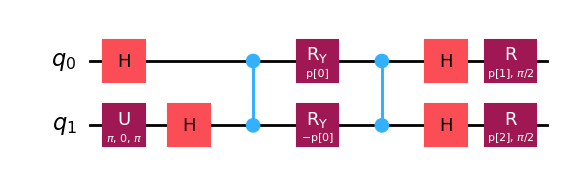

In [5]:
def pma_2q(nparam=3):
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(2)
    qc.x(1)
    rbs_block(qc, p[0])
    i = 1
    while i < nparam:
        qc.ry(p[i], 0); qc.ry(p[i + 1], 1)
        i += 2
    return qc

ansatz = pma_2q(3)
print(f"PMA-2q.3: {ansatz.num_parameters} parametri")
ansatz.decompose().draw("mpl")

## 4. VQE — multistart + polish

Metodologia confermata dal relatore per tutto il seguito del progetto:
multistart con $R=6$ restart, reinizializzazione casuale nel ciclo
**esterno** (non dentro le iterazioni dell'ottimizzatore), COBYLA.

**Aggiunta rispetto al notebook di confronto:** un polish finale con
L-BFGS-B dal miglior punto COBYLA. Lì l'obiettivo era un confronto
qualitativo fra ansatz su tutto un range di $b/J$; qui lo stato diventerà
l'input di un circuito quantistico a valle, quindi serve precisione
macchina — il residuo $\sim10^{-5}$ che COBYLA lascia da solo non basta.

In [6]:
def vqe_multistart(ansatz, H_op, w, v, R=6, maxiter=300, seed=0):
    rng = np.random.default_rng(seed)
    n = ansatz.num_parameters
    finals = []
    best = (np.inf, None, None)

    def obj(x):
        sv = Statevector(ansatz.assign_parameters(x))
        return float(np.real(sv.expectation_value(H_op)))

    for _ in range(R):
        x0 = rng.uniform(0.0, 2 * np.pi, n)
        res = minimize(obj, x0, method="COBYLA", options={"maxiter": maxiter})
        finals.append(res.fun)
        if res.fun < best[0]:
            best = (res.fun, res.x, res.nfev)
    Ebest, xbest, nfev = best

    # polish: L-BFGS-B dal miglior punto COBYLA
    res_polish = minimize(obj, xbest, method="L-BFGS-B")
    if res_polish.fun < Ebest:
        Ebest, xbest = res_polish.fun, res_polish.x

    sv = Statevector(ansatz.assign_parameters(xbest))
    fid = ground_fidelity(sv.data, w, v)
    return {"E": Ebest, "x": xbest, "fid": fid, "nfev": nfev,
            "finals": np.array(finals), "spread": np.ptp(finals),
            "statevector": sv}

In [7]:
H_op = dimer_hamiltonian(b, J, D)
result = vqe_multistart(ansatz, H_op, w, v, R=6, seed=0)

sv_vqe = result["statevector"].data
Mz_vqe = float(np.real(sv_vqe.conj() @ Mz_op.to_matrix() @ sv_vqe))
overlap = np.vdot(psi0_exact, sv_vqe)

print(f"E (VQE)       = {result['E']:.8f}")
print(f"|E_VQE - E0|  = {abs(result['E'] - E0_exact):.2e}")
print(f"Fidelity      = {result['fid']:.8f}")
print(f"Dispersione 6 restart (max-min energia, pre-polish) = {result['spread']:.2e}")
print(f"<Mz> (VQE)    = {Mz_vqe:.6f}\n")
print("Parametri ottimali (rad):", np.round(result["x"], 6))
print("\nStato VQE (base |00>,|01>,|10>,|11>):")
for lbl, amp in zip(["00", "01", "10", "11"], sv_vqe):
    print(f"  |{lbl}>: {amp: .6f}")
print(f"\n<psi_exact|psi_VQE> = {overlap:.6f}   (|.|={abs(overlap):.8f})")

E (VQE)       = -3.57321145
|E_VQE - E0|  = 7.14e-11
Fidelity      = 1.00000000
Dispersione 6 restart (max-min energia, pre-polish) = 6.69e-03
<Mz> (VQE)    = -0.034730

Parametri ottimali (rad): [3.978569 1.226724 1.914753]

Stato VQE (base |00>,|01>,|10>,|11>):
  |00>:  0.201713+0.000000j
  |01>:  0.664793+0.000000j
  |10>: -0.664789+0.000000j
  |11>:  0.274623+0.000000j

<psi_exact|psi_VQE> = 1.000000+0.000000j   (|.|=1.00000000)


**Lettura.** Fidelity a precisione macchina e overlap reale positivo:
nessuna fase relativa residua da fissare a mano prima di usare questo stato
come input di un circuito. $\langle M_z\rangle\simeq-0.035$ indica un
ground state vicino ma non dentro il settore $M=0$ — il DM con $D/J=0.8$
non è trascurabile e mescola i settori.

## 5. Diagnostica visiva

Tre grafici, sullo schema già usato nel resto del progetto per validare il
VQE: convergenza dell'ottimizzatore, ampiezze dello stato (esatto vs VQE),
collocazione sui livelli energetici.

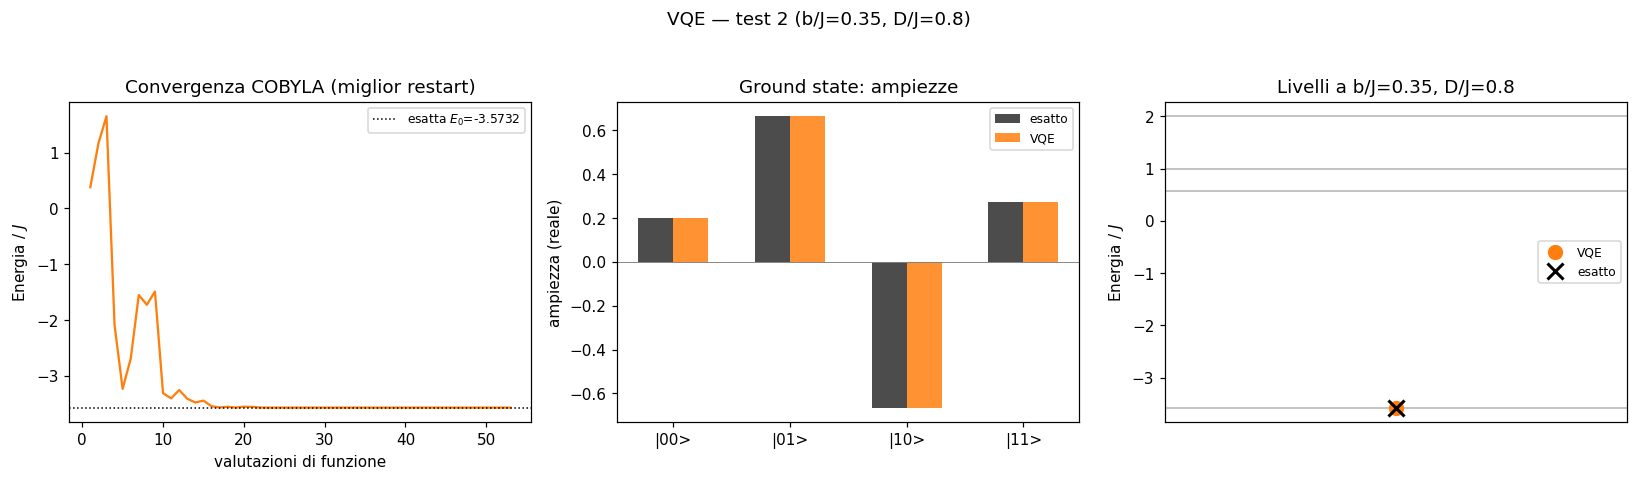

In [8]:
# --- convergenza (ricalcolo la history sulla corsa migliore per il grafico) ---
def vqe_with_history(ansatz, H_op, w, v, R=6, maxiter=300, seed=0):
    rng = np.random.default_rng(seed)
    n = ansatz.num_parameters
    best = (np.inf, None, None)
    for _ in range(R):
        x0 = rng.uniform(0.0, 2 * np.pi, n)
        hist = []
        def obj(x, hist=hist):
            e = float(np.real(Statevector(ansatz.assign_parameters(x)).expectation_value(H_op)))
            hist.append(e)
            return e
        res = minimize(obj, x0, method="COBYLA", options={"maxiter": maxiter})
        if res.fun < best[0]:
            best = (res.fun, res.x, hist)
    return best

_, _, history = vqe_with_history(ansatz, H_op, w, v, R=6, seed=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# 1) convergenza
axes[0].plot(range(1, len(history) + 1), history, "-", color="tab:orange", lw=1.5)
axes[0].axhline(E0_exact, color="k", ls=":", lw=1, label=f"esatta $E_0$={E0_exact:.4f}")
axes[0].set_xlabel("valutazioni di funzione"); axes[0].set_ylabel("Energia / $J$")
axes[0].set_title("Convergenza COBYLA (miglior restart)"); axes[0].legend(fontsize=8)

# 2) ampiezze esatto vs VQE
labels = ["00", "01", "10", "11"]
x = np.arange(4)
axes[1].bar(x - 0.15, np.real(psi0_exact), width=0.3, label="esatto", color="k", alpha=0.7)
axes[1].bar(x + 0.15, np.real(sv_vqe), width=0.3, label="VQE", color="tab:orange", alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels([f"|{l}>" for l in labels])
axes[1].axhline(0, color="0.5", lw=0.6)
axes[1].set_ylabel("ampiezza (reale)"); axes[1].set_title("Ground state: ampiezze")
axes[1].legend(fontsize=8)

# 3) livelli energetici con il punto VQE
for k in range(4):
    axes[2].axhline(w[k], color="0.7", lw=1)
axes[2].plot(0, result["E"], "o", ms=9, color="tab:orange", label="VQE")
axes[2].plot(0, E0_exact, "x", ms=10, mew=2, color="k", label="esatto")
axes[2].set_xlim(-1, 1); axes[2].set_xticks([])
axes[2].set_ylabel("Energia / $J$"); axes[2].set_title(f"Livelli a b/J={B_SU_J}, D/J={D_SU_J}")
axes[2].legend(fontsize=8)

fig.suptitle(f"VQE — test 2 (b/J={B_SU_J}, D/J={D_SU_J})", y=1.03)
fig.tight_layout()
_mostra_figura(fig)

## 6. Esplorazione interattiva (facoltativa)

I due cursori permettono di verificare il comportamento del VQE (fidelity,
dispersione del multistart) in un intorno del punto di lavoro del test 2,
utile come controllo di robustezza. Il pulsante **Fissa questi parametri**
non modifica il punto di lavoro del test 2 usato in tutto il notebook
(rimane quello fissato in §2); serve solo per esplorare senza rieseguire
manualmente le celle.

In [9]:
try:
    import ipywidgets as W

    s_b = W.FloatSlider(value=B_SU_J, min=-1.0, max=1.0, step=0.01,
                         description="b/J:", continuous_update=False, readout_format=".2f")
    s_D = W.FloatSlider(value=D_SU_J, min=0.0, max=2.0, step=0.05,
                         description="D/J:", continuous_update=False, readout_format=".2f")
    uscita = W.Output()
    _in_corso = [False]

    def _esplora(b_su_J, D_su_J):
        E0, psi0, w_, v_ = exact_ground(b_su_J, J, D_su_J)
        H_ = dimer_hamiltonian(b_su_J, J, D_su_J)
        r = vqe_multistart(ansatz, H_, w_, v_, R=6, seed=0)

        fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
        labels = ["00", "01", "10", "11"]
        x = np.arange(4)
        axes[0].bar(x - 0.15, np.real(psi0), width=0.3, label="esatto", color="k", alpha=0.7)
        axes[0].bar(x + 0.15, np.real(r["statevector"].data), width=0.3,
                    label="VQE", color="tab:orange", alpha=0.85)
        axes[0].set_xticks(x); axes[0].set_xticklabels([f"|{l}>" for l in labels])
        axes[0].axhline(0, color="0.5", lw=0.6); axes[0].legend(fontsize=8)
        axes[0].set_title(f"b/J={b_su_J:.2f}  D/J={D_su_J:.2f}")

        for k in range(4):
            axes[1].axhline(w_[k], color="0.7", lw=1)
        axes[1].plot(0, r["E"], "o", ms=9, color="tab:orange")
        axes[1].set_xlim(-1, 1); axes[1].set_xticks([]); axes[1].set_title("Livelli")

        fig.tight_layout()
        return fig, r["fid"], r["spread"]

    def _render(b_su_J, D_su_J):
        if _in_corso[0]:
            return
        _in_corso[0] = True
        try:
            fig, fid, spread = _esplora(b_su_J, D_su_J)
            with uscita:
                uscita.clear_output(wait=True)
                _mostra_figura(fig)
                print(f"Fidelity = {fid:.8f}   dispersione multistart = {spread:.2e}")
        finally:
            _in_corso[0] = False

    _collegamento = W.interactive_output(_render, {"b_su_J": s_b, "D_su_J": s_D})
    display(W.VBox([W.HBox([s_b, s_D]), uscita]))
    _render(s_b.value, s_D.value)

except ImportError:
    print("ipywidgets non disponibile: esplorazione manuale, es.")
    print("  exact_ground(0.35, 1.0, 0.80)")

## 7. Salvataggio dello stato

Il ground state VQE al punto del test 2 (indipendente dall'esplorazione
interattiva della sezione precedente) viene salvato per lo stadio
successivo: preparazione come stato iniziale nel circuito con l'ancilla per
le correlazioni dinamiche.

In [11]:
np.savez("ground_state_test2.npz",
         b=b, J=J, D=D,
         E0_exact=E0_exact, E_vqe=result["E"], fidelity=result["fid"],
         psi0_exact=psi0_exact, psi0_vqe=sv_vqe,
         vqe_params=result["x"])
print("[salvato] ground_state_test2.npz")

[salvato] ground_state_test2.npz
